# TSA Insurance Claims Analysis

## Project Overview

I wanted to dig into the public TSA claims dataset to see what patterns show up when travelers file claims against airport security. The data covers about a decade of claims filed against the Transportation Security Administration, and I was curious about a few things: what kinds of claims happen most, where in the airport they happen, how much money is involved, how often the TSA actually pays, and which airports generate the most issues.

This notebook walks through the cleaning steps and then answers those questions one by one. The final section maps the results geographically using GeoPandas so you can see which parts of the country generate the most claim volume. I also fit a simple logistic regression to see whether the available features can predict whether a claim will be approved.

**Dataset**: TSA Claims Data (publicly released on data.gov), combined with the Global Airport Database for coordinates.

**Tools**: Python, pandas, NumPy, matplotlib, GeoPandas, Shapely, scikit-learn.


## Setup

Imports and display settings.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import geopandas as gpd
from shapely.geometry import Point
import zipfile, os

os.makedirs('figures', exist_ok=True)

pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:,.2f}'.format)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

## Loading the Data

The TSA claims file and the airport database both sit in the `data/` folder. The states shapefile lives inside `data/maps.zip`, so I unzip it first.

In [2]:
if not os.path.exists('data/maps'):
    with zipfile.ZipFile('data/maps.zip', 'r') as z:
        z.extractall('data/')
    print('Extracted shapefile.')

tsa = pd.read_csv('data/tsa_claims2.csv', low_memory=False)
airports = pd.read_csv('data/GlobalAirportDatabase.csv', low_memory=False)

print(f'TSA claims rows: {len(tsa):,}')
print(f'Airport DB rows: {len(airports):,}')
print()
print('TSA columns:', tsa.columns.tolist())

TSA claims rows: 204,267
Airport DB rows: 9,300

TSA columns: ['Claim Number', 'Date Received', 'Incident Date', 'Airport Code', 'Airport Name', 'Airline Name', 'Claim Type', 'Claim Site', 'Item', 'Claim Amount', 'Status', 'Close Amount', 'Disposition']


In [3]:
tsa.head()

,Claim Number,Date Received,Incident Date,Airport Code,Airport Name,Airline Name,Claim Type,Claim Site,Item,Claim Amount,Status,Close Amount,Disposition
0,0909802M,4-Jan-02,12/12/2002 0:00,EWR,Newark International Airport,Continental Airlines,Property Damage,Checkpoint,Other,$350.00,Approved,$350.00,Approve in Full
1,0202417M,2-Feb-02,1/16/2004 0:00,SEA,Seattle-Tacoma International,NaN,Property Damage,Checked Baggage,Luggage (all types including footlockers),$100.00,Settled,$50.00,Settle
2,0202445M,4-Feb-02,11/26/2003 0:00,STL,Lambert St. Louis International,American Airlines,Property Damage,Checked Baggage,Cell Phones,$278.88,Settled,$227.92,Settle
3,0909816M,7-Feb-02,1/6/2003 0:00,MIA,Miami International Airport,American Airlines,Property Damage,Checkpoint,Luggage (all types including footlockers),$50.00,Approved,$50.00,Approve in Full
4,2005032379513,18-Feb-02,2/5/2005 0:00,MCO,Orlando International Airport,Delta (Song),Property Damage,Checkpoint,Baby - Strollers; car seats; playpen; etc.,$84.79,Approved,$84.79,Approve in Full


## Data Cleaning

The raw file has a few annoyances I needed to fix before any analysis would work. Dates are stored as strings in formats like `4-Jan-02`, currency columns include dollar signs and commas, the placeholder `-` shows up in categorical columns instead of NaN, and the Status column has duplicates like `Approve in Full` vs `Approved`. I handle all of those below.

In [ ]:
tsa.replace('-', np.nan, inplace=True)
str_cols = tsa.select_dtypes(include='object').columns
tsa[str_cols] = tsa[str_cols].apply(lambda col: col.str.strip())

tsa['Date Received'] = pd.to_datetime(tsa['Date Received'], errors='coerce')
tsa['Incident Date'] = pd.to_datetime(tsa['Incident Date'], errors='coerce')
tsa['Year'] = tsa['Date Received'].dt.year

print('Date range before sanity filter:', tsa['Date Received'].min(), 'to', tsa['Date Received'].max())

# Two-digit years in the source dates are ambiguous (e.g. "17-May-55" parses
# to 2055, not 1955), and a handful of rows land decades outside the claims
# program's actual operating window. An impossible year like 2055 would
# otherwise flow untouched into 'Year' as a raw numeric feature for the
# approval model below, quietly distorting its one time-based predictor.
# Anything outside the range this dataset can plausibly cover is dropped.
valid_year = tsa['Date Received'].dt.year.between(2002, 2016)
dropped = (~valid_year).sum()
tsa = tsa[valid_year].copy()
tsa['Year'] = tsa['Date Received'].dt.year
print(f'Dropped {dropped} rows with an implausible Date Received (e.g. mis-parsed two-digit years)')
print('Date range after sanity filter:', tsa['Date Received'].min(), 'to', tsa['Date Received'].max())

In [5]:
def parse_currency(series):
    return (
        series.astype(str)
              .str.replace(r'[\$,]', '', regex=True)
              .replace('nan', np.nan)
              .pipe(pd.to_numeric, errors='coerce')
    )

tsa['Claim Amount'] = parse_currency(tsa['Claim Amount'])
tsa['Close Amount'] = parse_currency(tsa['Close Amount'])

status_map = {'Approve in Full': 'Approved', 'Deny': 'Denied', 'Settle': 'Settled'}
tsa['Status'] = tsa['Status'].replace(status_map)

print('Final shape:', tsa.shape)
print()
print('Status values after cleaning:')
print(tsa['Status'].value_counts(dropna=False))

Final shape: (204267, 14)

Status values after cleaning:
Status
Denied                                                                                                                           96576
Approved                                                                                                                         47363
Settled                                                                                                                          33724
NaN                                                                                                                              12757
Canceled                                                                                                                          7018
Insufficient; one of the following items required: sum certain; statement of fact; signature; location of incident; and date.     5381
Closed as a contractor claim                                                                                                  

## What Kinds of Claims Are Most Common?

First I wanted to see the breakdown of claim types. This tells us what travelers are most often unhappy about.

In [6]:
claim_type_counts = (
    tsa['Claim Type']
    .value_counts(dropna=True)
    .rename_axis('Claim Type')
    .reset_index(name='Count')
)
claim_type_counts['Percent'] = (claim_type_counts['Count'] / claim_type_counts['Count'].sum() * 100).round(1)
print(claim_type_counts.to_string(index=False))

             Claim Type  Count  Percent
Passenger Property Loss 117868    60.10
        Property Damage  75364    38.40
        Personal Injury   1465     0.70
 Employee Loss (MPCECA)    485     0.20
        Passenger Theft    465     0.20
          Motor Vehicle    369     0.20
              Complaint     48     0.00
         Wrongful Death      4     0.00
             Compliment      3     0.00
           Bus Terminal      1     0.00


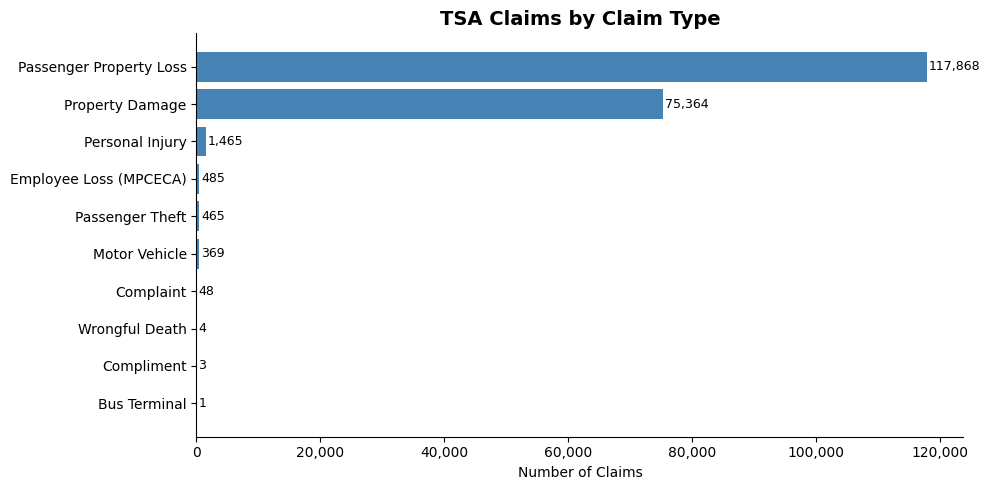

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(claim_type_counts['Claim Type'][::-1], claim_type_counts['Count'][::-1], color='steelblue')
ax.set_xlabel('Number of Claims')
ax.set_title('TSA Claims by Claim Type', fontsize=14, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for bar in bars:
    w = bar.get_width()
    ax.text(w + 300, bar.get_y() + bar.get_height()/2, f'{w:,.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('figures/claim_types.png', dpi=150, bbox_inches='tight')
plt.show()

## Where in the Airport Do Claims Happen?

Next I broke claims down by the location at the airport where the incident occurred.

In [8]:
claim_site_counts = (
    tsa['Claim Site']
    .value_counts(dropna=True)
    .rename_axis('Claim Site')
    .reset_index(name='Count')
)
claim_site_counts['Percent'] = (claim_site_counts['Count'] / claim_site_counts['Count'].sum() * 100).round(1)
print(claim_site_counts.to_string(index=False))

     Claim Site  Count  Percent
Checked Baggage 159753    78.60
     Checkpoint  40133    19.70
          Other   2875     1.40
  Motor Vehicle    474     0.20
    Bus Station     16     0.00


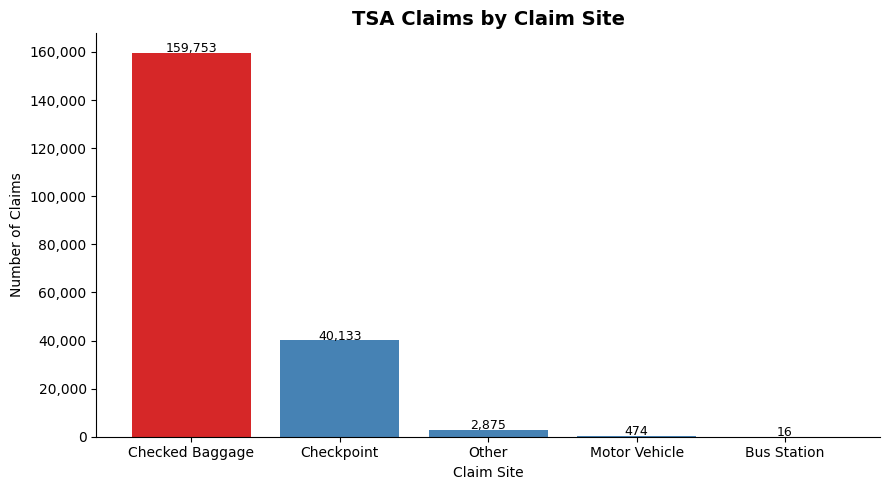

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#d62728' if i == 0 else 'steelblue' for i in range(len(claim_site_counts))]
ax.bar(claim_site_counts['Claim Site'], claim_site_counts['Count'], color=colors)
ax.set_xlabel('Claim Site')
ax.set_ylabel('Number of Claims')
ax.set_title('TSA Claims by Claim Site', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for bar in ax.patches:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 200, f'{h:,.0f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('figures/claim_sites.png', dpi=150, bbox_inches='tight')
plt.show()

## Claim Type by Site

Combining the two, what type of claim shows up most at each location?

In [10]:
site_type = (
    tsa.dropna(subset=['Claim Site', 'Claim Type'])
       .groupby(['Claim Site', 'Claim Type'])
       .size()
       .rename('Count')
       .reset_index()
)

top_per_site = (
    site_type
    .sort_values('Count', ascending=False)
    .groupby('Claim Site')
    .first()
    .reset_index()
    .rename(columns={'Claim Type': 'Most Common Claim Type'})
)
print(top_per_site.to_string(index=False))

     Claim Site  Most Common Claim Type  Count
    Bus Station Passenger Property Loss      9
Checked Baggage Passenger Property Loss  99708
     Checkpoint         Property Damage  20572
  Motor Vehicle           Motor Vehicle    320
          Other         Property Damage    477


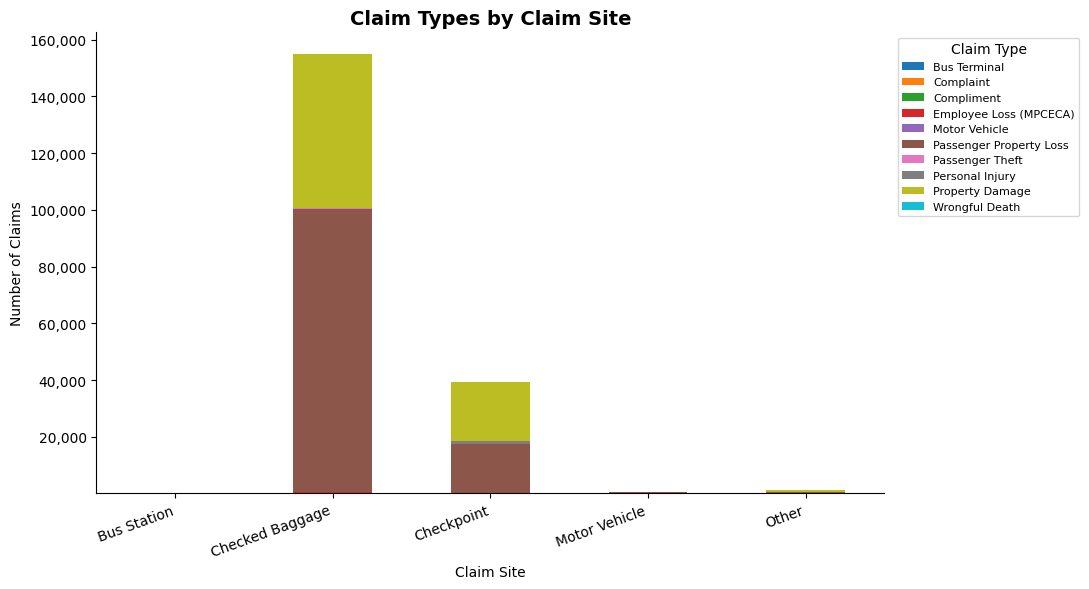

In [11]:
pivot = (
    site_type
    .pivot_table(index='Claim Site', columns='Claim Type', values='Count', fill_value=0)
)
pivot.plot(kind='bar', stacked=True, figsize=(11, 6), colormap='tab10')
plt.title('Claim Types by Claim Site', fontsize=14, fontweight='bold')
plt.xlabel('Claim Site')
plt.ylabel('Number of Claims')
plt.xticks(rotation=20, ha='right')
plt.legend(title='Claim Type', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig('figures/site_by_type.png', dpi=150, bbox_inches='tight')
plt.show()

## How Much Money Are People Asking For?

The claim amount distribution is heavily right-skewed (a few claims for huge amounts pull the mean up), so I report both the mean and median, plus a histogram capped at the 99th percentile so the rare massive claims do not flatten everything else.

In [12]:
claim_amt = tsa['Claim Amount'].dropna()

stats = {
    'Count': f"{len(claim_amt):,}",
    'Mean': f"${claim_amt.mean():,.2f}",
    'Median': f"${claim_amt.median():,.2f}",
    'Std Dev': f"${claim_amt.std():,.2f}",
    'Min': f"${claim_amt.min():,.2f}",
    'Max': f"${claim_amt.max():,.2f}",
    '25th pct': f"${claim_amt.quantile(0.25):,.2f}",
    '75th pct': f"${claim_amt.quantile(0.75):,.2f}",
}
stats_df = pd.DataFrame(list(stats.items()), columns=['Statistic', 'Value'])
print(stats_df.to_string(index=False))

Statistic   Value
    Count 168,588
     Mean $173.00
   Median  $95.00
  Std Dev $208.69
      Min   $0.00
      Max $999.99
 25th pct  $20.77
 75th pct $250.00


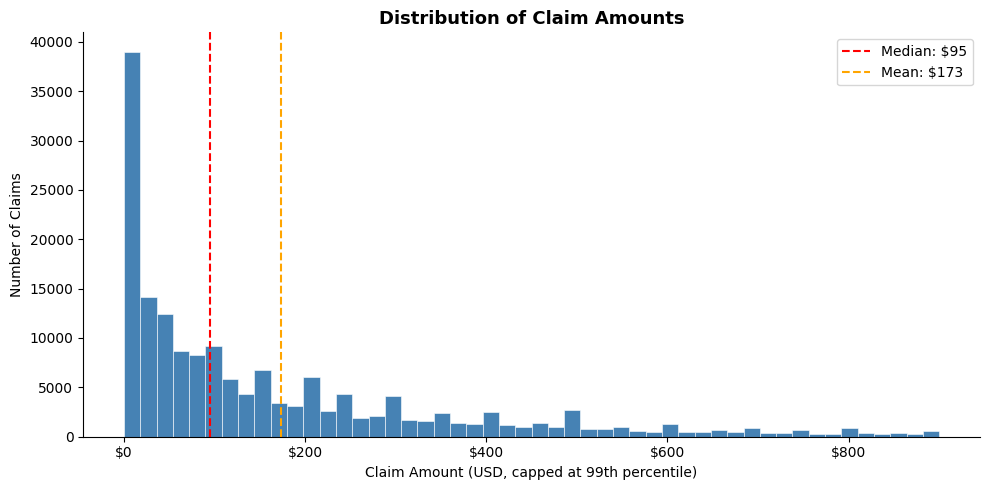

In [13]:
cap = claim_amt.quantile(0.99)
capped = claim_amt[claim_amt <= cap]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(capped, bins=50, color='steelblue', edgecolor='white', linewidth=0.4)
ax.axvline(claim_amt.median(), color='red', linestyle='--', linewidth=1.5,
           label=f'Median: ${claim_amt.median():,.0f}')
ax.axvline(claim_amt.mean(), color='orange', linestyle='--', linewidth=1.5,
           label=f'Mean: ${claim_amt.mean():,.0f}')
ax.set_xlabel('Claim Amount (USD, capped at 99th percentile)')
ax.set_ylabel('Number of Claims')
ax.set_title('Distribution of Claim Amounts', fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.savefig('figures/claim_amount_dist.png', dpi=150, bbox_inches='tight')
plt.show()

## Approval Rates

How often does the TSA actually approve a claim? I grouped by the cleaned Status column and looked at the share of each outcome.

                                                                                                                               Count  Percent
Status                                                                                                                                       
Denied                                                                                                                         96576    50.40
Approved                                                                                                                       47363    24.70
Settled                                                                                                                        33724    17.60
Canceled                                                                                                                        7018     3.70
Insufficient; one of the following items required: sum certain; statement of fact; signature; location of incident; and date.   5381     2.80
Closed

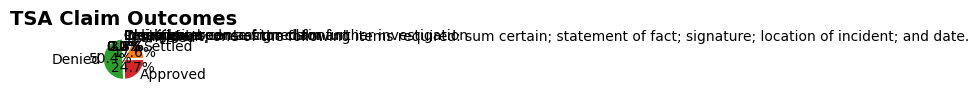

In [14]:
status_counts = tsa['Status'].value_counts(dropna=True)
status_pct = (status_counts / status_counts.sum() * 100).round(1)

approval_df = pd.DataFrame({'Count': status_counts, 'Percent': status_pct})
print(approval_df.to_string())

fig, ax = plt.subplots(figsize=(7, 7))
colors_pie = ['#2ca02c', '#d62728', '#ff7f0e', '#1f77b4', '#9467bd']
ax.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%',
       colors=colors_pie[:len(status_counts)], startangle=90,
       wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax.set_title('TSA Claim Outcomes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/approval_rate.png', dpi=150, bbox_inches='tight')
plt.show()

## When the TSA Pays, How Much Do They Pay?

For claims that were Approved or Settled, I calculated what percent of the claimed amount was actually paid out. This tells us whether approval translates to full reimbursement or just a partial settlement.

In [15]:
paid = tsa[
    tsa['Status'].isin(['Approved', 'Settled']) &
    tsa['Claim Amount'].notna() &
    tsa['Close Amount'].notna() &
    (tsa['Claim Amount'] > 0)
].copy()
paid['Pct Paid'] = (paid['Close Amount'] / paid['Claim Amount'] * 100).clip(upper=100)

pct_stats = {
    'Count': f"{len(paid):,}",
    'Mean %': f"{paid['Pct Paid'].mean():.1f}%",
    'Median %': f"{paid['Pct Paid'].median():.1f}%",
    'Total Claimed': f"${paid['Claim Amount'].sum():,.0f}",
    'Total Paid': f"${paid['Close Amount'].sum():,.0f}",
    'Overall Pct': f"{paid['Close Amount'].sum() / paid['Claim Amount'].sum() * 100:.1f}%",
}
pct_df = pd.DataFrame(list(pct_stats.items()), columns=['Metric', 'Value'])
print(pct_df.to_string(index=False))

       Metric       Value
        Count      58,646
       Mean %       79.6%
     Median %      100.0%
Total Claimed $10,125,859
   Total Paid  $7,107,150
  Overall Pct       70.2%


          Total_Claimed   Total_Paid  Count  Pct_Paid
Status                                               
Approved   3,893,346.60 3,870,830.40  33973     99.40
Settled    6,232,512.60 3,236,319.20  24673     51.90


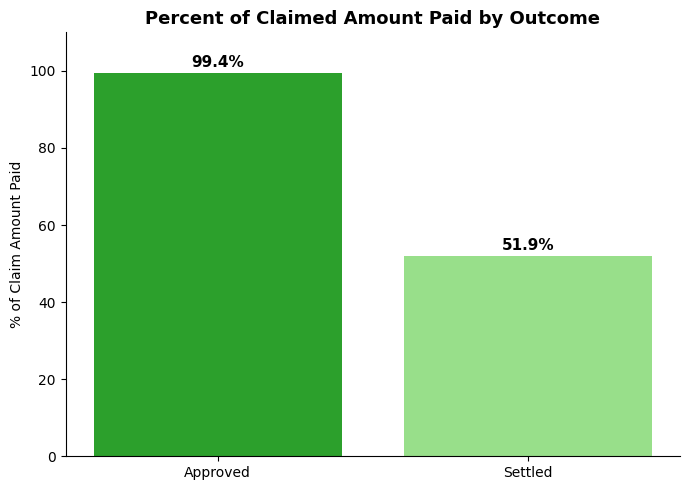

In [16]:
pct_by_status = (
    paid.groupby('Status')
        .agg(Total_Claimed=('Claim Amount', 'sum'),
             Total_Paid=('Close Amount', 'sum'),
             Count=('Claim Amount', 'count'))
        .assign(Pct_Paid=lambda df: df['Total_Paid'] / df['Total_Claimed'] * 100)
        .round(1)
)
print(pct_by_status)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(pct_by_status.index, pct_by_status['Pct_Paid'], color=['#2ca02c', '#98df8a'])
ax.set_ylim(0, 110)
ax.set_ylabel('% of Claim Amount Paid')
ax.set_title('Percent of Claimed Amount Paid by Outcome', fontsize=13, fontweight='bold')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f'{bar.get_height():.1f}%', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/pct_paid.png', dpi=150, bbox_inches='tight')
plt.show()

## Which Airports Generate the Most Claims?

Total claim count by airport. Airports with more passenger traffic will naturally have more claims, so this is partly a measure of throughput, but it is still useful for understanding where the volume sits.

In [17]:
top5 = (
    tsa.dropna(subset=['Airport Code'])
       .groupby(['Airport Code', 'Airport Name'])
       .size()
       .rename('Total Claims')
       .reset_index()
       .sort_values('Total Claims', ascending=False)
       .head(5)
       .reset_index(drop=True)
)
top5.index += 1
print(top5.to_string())

  Airport Code                          Airport Name  Total Claims
1          LAX     Los Angeles International Airport          9596
2          JFK         John F. Kennedy International          9232
3          EWR          Newark International Airport          6866
4          ORD  Chicago O'Hare International Airport          6843
5          MIA           Miami International Airport          6432


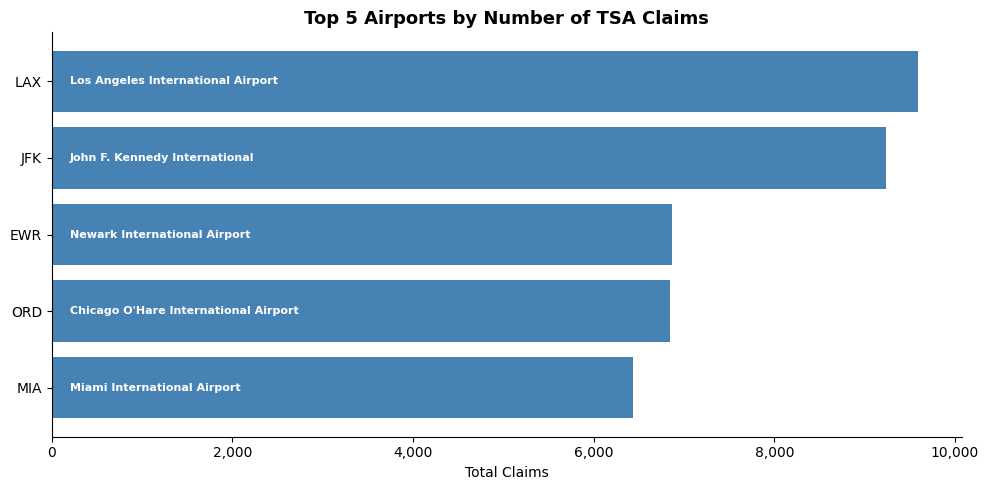

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top5['Airport Code'][::-1], top5['Total Claims'][::-1], color='steelblue')
ax.set_xlabel('Total Claims')
ax.set_title('Top 5 Airports by Number of TSA Claims', fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for i, (_, row) in enumerate(top5[::-1].iterrows()):
    ax.text(200, i, row['Airport Name'], va='center', fontsize=8, color='white', fontweight='bold')
plt.tight_layout()
plt.savefig('figures/top5_airports.png', dpi=150, bbox_inches='tight')
plt.show()

## Trends Over Time

Has total payout grown or shrunk year over year? I plotted total close amount and the number of claims as two panels on a shared x-axis (year) rather than one chart with a twin y-axis, since a dual-axis chart lets either axis's range be picked to make the two series line up or diverge however you like, which can manufacture a "the trends match" story the data doesn't actually support.

In [19]:
annual = (
    tsa.dropna(subset=['Year', 'Close Amount'])
       .groupby('Year')
       .agg(Total_Close_Amount=('Close Amount', 'sum'),
            Claim_Count=('Close Amount', 'count'))
       .reset_index()
)
annual = annual[(annual['Year'] >= 2002) & (annual['Year'] <= 2015)]
annual['Total_Close_Amount_M'] = annual['Total_Close_Amount'] / 1_000_000
print(annual[['Year', 'Claim_Count', 'Total_Close_Amount']].to_string(index=False))

    Year  Claim_Count  Total_Close_Amount
2,002.00          755          102,950.43
2,003.00        19180        1,772,028.28
2,004.00        26595        2,401,358.94
2,005.00        22990        1,451,356.00
2,006.00        18097        1,085,467.94
2,007.00        17918          708,277.15
2,008.00        15644          513,127.05
2,009.00        11915          413,987.85


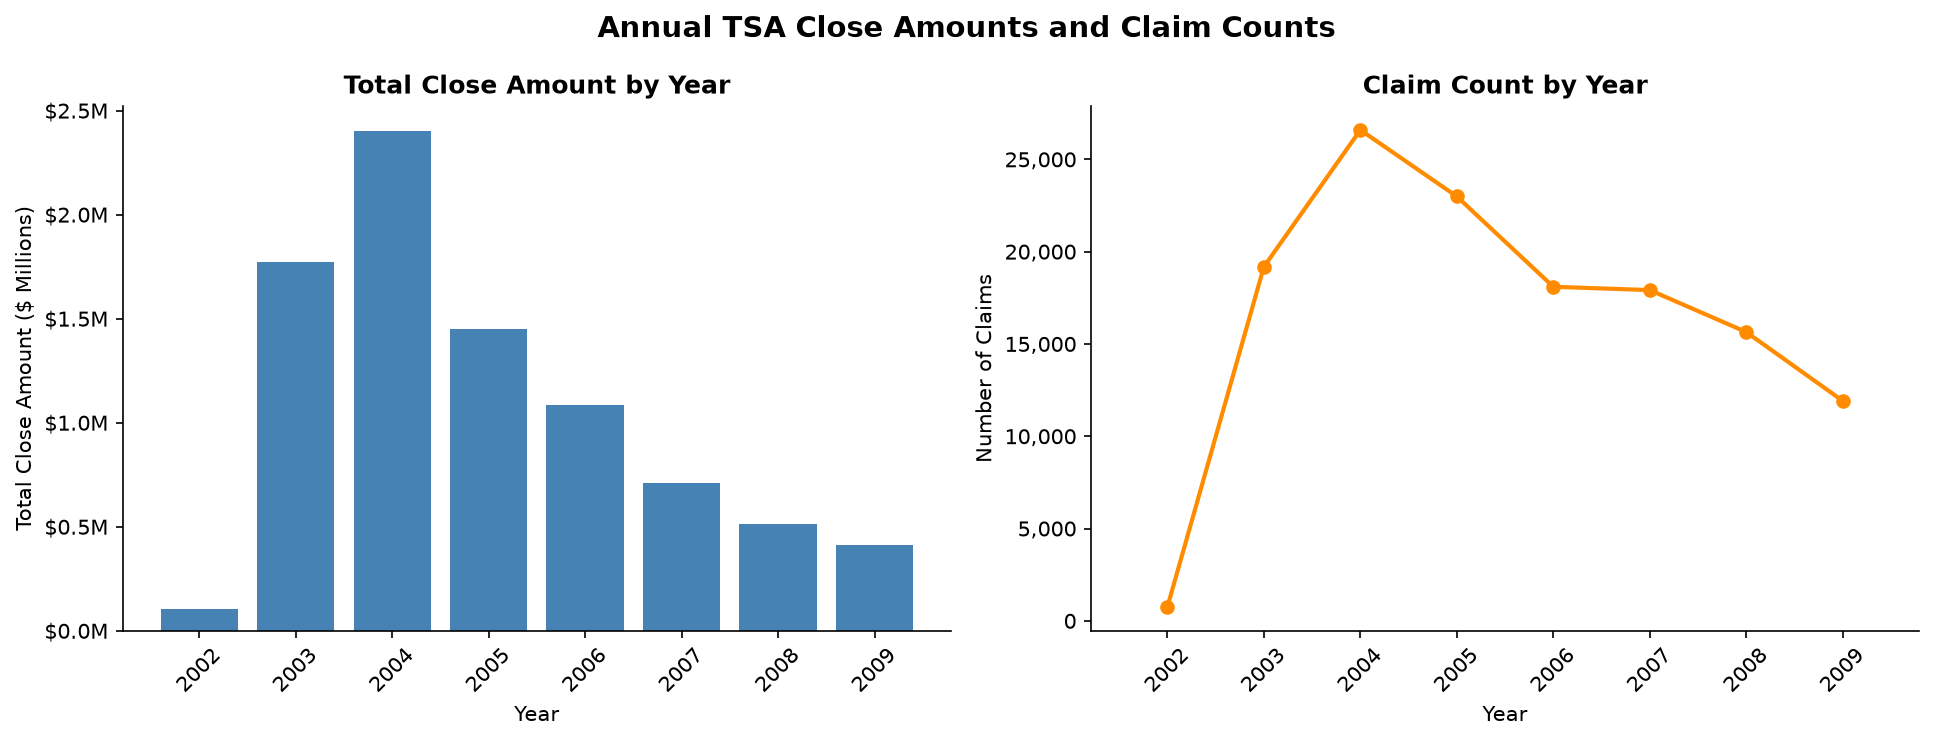

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), sharex=True)

ax1.bar(annual['Year'], annual['Total_Close_Amount_M'], color='steelblue')
ax1.set_xlabel('Year')
ax1.set_ylabel('Total Close Amount ($ Millions)')
ax1.set_title('Total Close Amount by Year', fontsize=12, fontweight='bold')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}M'))

ax2.plot(annual['Year'], annual['Claim_Count'], color='darkorange', marker='o', linewidth=2)
ax2.set_xlabel('Year')
ax2.set_ylabel('Number of Claims')
ax2.set_title('Claim Count by Year', fontsize=12, fontweight='bold')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

for ax in (ax1, ax2):
    ax.set_xticks(annual['Year'])
    ax.set_xticklabels(annual['Year'].astype(int), rotation=45)

fig.suptitle('Annual TSA Close Amounts and Claim Counts', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/trend_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

## Predictive Model: Will a Claim Get Approved?

Beyond the descriptive analysis, I wanted to see if the available features could predict the outcome of a claim. I built a logistic regression that uses claim type, claim site, claim amount, and year to predict whether a claim will be Approved (or Settled) versus Denied. This is a binary classification problem with a moderately imbalanced target.

I am keeping the model deliberately simple. The point is to see whether there is signal at all and which features matter, not to build a production system.

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

model_df = tsa[
    tsa['Status'].isin(['Approved', 'Denied', 'Settled']) &
    tsa['Claim Type'].notna() &
    tsa['Claim Site'].notna() &
    tsa['Claim Amount'].notna() &
    tsa['Year'].notna()
].copy()

model_df['target'] = (model_df['Status'].isin(['Approved', 'Settled'])).astype(int)

features = ['Claim Type', 'Claim Site', 'Claim Amount', 'Year']
X = model_df[features]
y = model_df['target']

print(f'Modeling dataset size: {len(model_df):,} claims')
print(f'Approval rate (target=1): {y.mean():.1%}')

Modeling dataset size: 154,645 claims
Approval rate (target=1): 47.1%


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

cat_features = ['Claim Type', 'Claim Site']
num_features = ['Claim Amount', 'Year']

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
    ('num', StandardScaler(), num_features),
])

pipe = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced')),
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)[:, 1]

print('Classification report:')
print(classification_report(y_test, y_pred, target_names=['Denied', 'Approved/Settled']))
print(f'ROC AUC: {roc_auc_score(y_test, y_proba):.3f}')

Classification report:
                  precision    recall  f1-score   support

          Denied       0.68      0.64      0.66     20471
Approved/Settled       0.62      0.66      0.64     18191

        accuracy                           0.65     38662
       macro avg       0.65      0.65      0.65     38662
    weighted avg       0.65      0.65      0.65     38662

ROC AUC: 0.664


## Confusion Matrix

The classification report gives precision and recall; the confusion matrix shows the raw counts behind them. Because the model uses balanced class weights, it deliberately trades a little precision to catch more of the minority Approved/Settled class, so the off-diagonal false positives are expected.

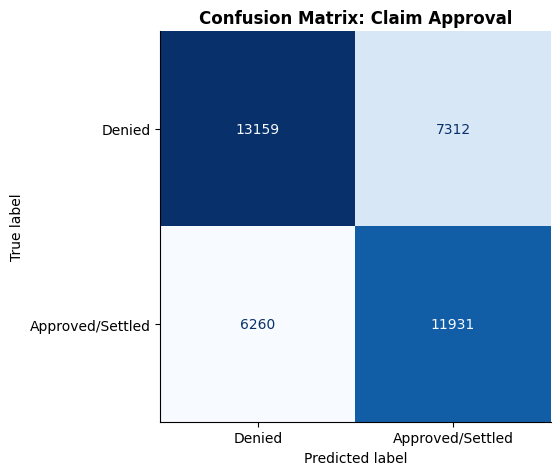

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5.5, 5))
ConfusionMatrixDisplay(cm, display_labels=['Denied', 'Approved/Settled']).plot(
    ax=ax, cmap='Blues', colorbar=False, values_format='d'
)
ax.set_title('Confusion Matrix: Claim Approval', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

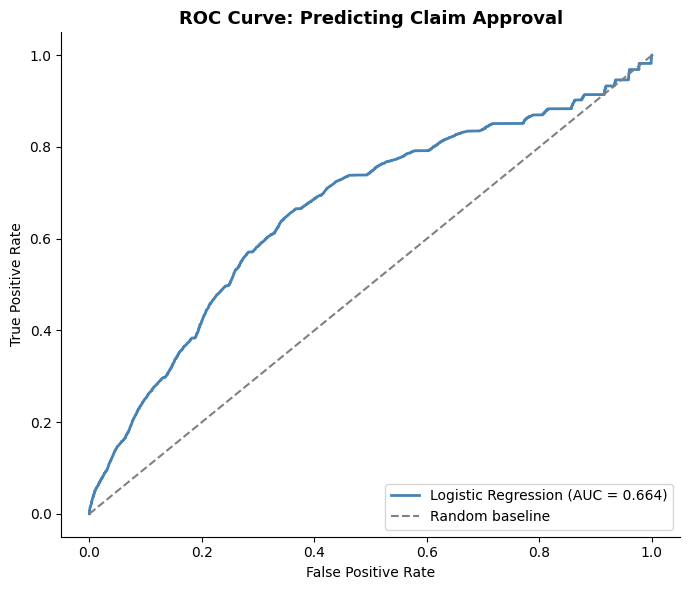

In [24]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='steelblue', linewidth=2, label=f'Logistic Regression (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve: Predicting Claim Approval', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('figures/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

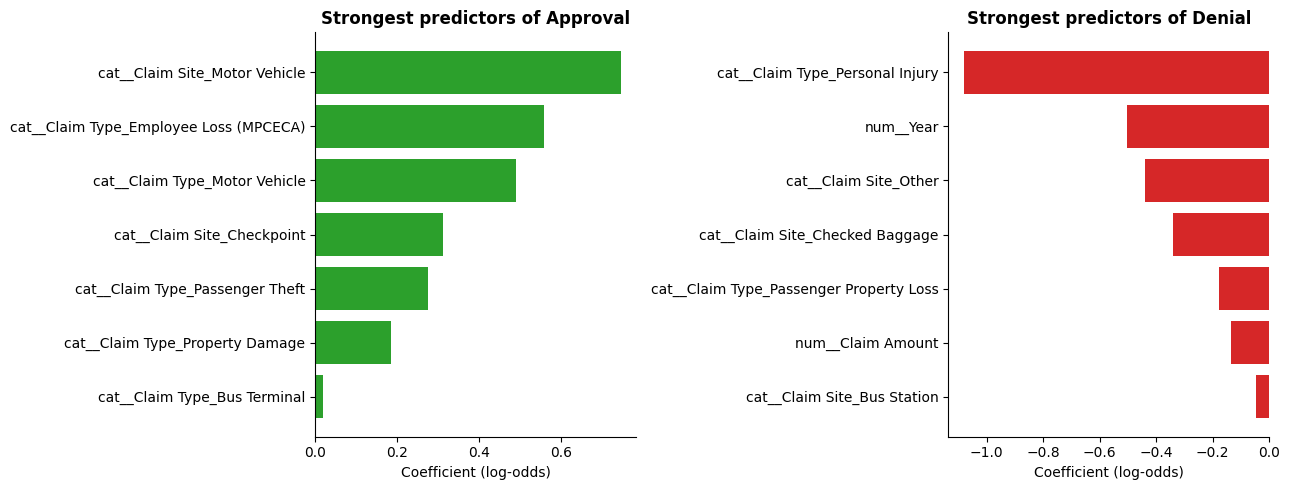

In [25]:
feat_names = pipe.named_steps['prep'].get_feature_names_out()
coefs = pipe.named_steps['clf'].coef_[0]

coef_df = pd.DataFrame({'feature': feat_names, 'coef': coefs})
coef_df = coef_df.reindex(coef_df['coef'].abs().sort_values(ascending=False).index)

top_pos = coef_df[coef_df['coef'] > 0].head(7)
top_neg = coef_df[coef_df['coef'] < 0].head(7)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].barh(top_pos['feature'][::-1], top_pos['coef'][::-1], color='#2ca02c')
axes[0].set_title('Strongest predictors of Approval', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Coefficient (log-odds)')
axes[1].barh(top_neg['feature'][::-1], top_neg['coef'][::-1], color='#d62728')
axes[1].set_title('Strongest predictors of Denial', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Coefficient (log-odds)')
plt.tight_layout()
plt.savefig('figures/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## Geographic View

Finally I plotted every airport that appears in the claims data on a U.S. map, with marker size scaled to claim count. The top five airports are labeled in red so you can spot them easily.

In [26]:
airport_claims = (
    tsa.dropna(subset=['Airport Code'])
       .groupby('Airport Code')
       .size()
       .rename('Claim Count')
       .reset_index()
)

airports_clean = airports[
    (airports['Country'] == 'USA') &
    (airports['LatitudeDecimalDegrees'].notna()) &
    (airports['LongitudeDecimalDegrees'].notna()) &
    (airports['LatitudeDecimalDegrees'] != 0)
][['IATACode', 'AirportName', 'LatitudeDecimalDegrees', 'LongitudeDecimalDegrees']].copy()
airports_clean.columns = ['Airport Code', 'AirportName', 'Latitude', 'Longitude']

geo_df = airport_claims.merge(airports_clean, on='Airport Code', how='inner')

geometry = [Point(lon, lat) for lon, lat in zip(geo_df['Longitude'], geo_df['Latitude'])]
geo_gdf = gpd.GeoDataFrame(geo_df, geometry=geometry, crs='EPSG:4326')

geo_gdf = geo_gdf[
    (geo_gdf['Longitude'].between(-130, -60)) &
    (geo_gdf['Latitude'].between(20, 55))
]
print(f'Continental US airports plotted: {len(geo_gdf)}')

Continental US airports plotted: 197


In [ ]:
states = gpd.read_file('data/maps/states.shp').to_crs('EPSG:4326')

fig, ax = plt.subplots(figsize=(14, 9))
states.plot(ax=ax, color='#f0f0f0', edgecolor='#999999', linewidth=0.5)

marker_sizes = (geo_gdf['Claim Count'] / geo_gdf['Claim Count'].max()) ** 0.5 * 600
geo_gdf.plot(ax=ax, markersize=marker_sizes, color='steelblue', alpha=0.6,
             edgecolor='white', linewidth=0.3)

# Two of the labeled airports (JFK and EWR) sit ~15 miles apart, which at
# this continental-US zoom level is close enough that a fixed (5, 5) point
# offset stacks their labels into unreadable overlapping text. Any labeled
# pair closer than ~1 degree gets pushed further apart with a thin leader
# line instead of the default offset, so nearby labels stay legible without
# hand-coding specific airport codes.
top5_codes = top5['Airport Code'].tolist()
labeled = geo_gdf[geo_gdf['Airport Code'].isin(top5_codes)].reset_index(drop=True)

DEFAULT_OFFSET = (5, 5)
NUDGE_RING = [(18, 18), (18, -22), (-38, 10), (-38, -22), (0, 26)]
close_threshold_deg = 1.0

offsets = [DEFAULT_OFFSET] * len(labeled)
for i in range(len(labeled)):
    for j in range(i):
        dx = labeled.geometry.x[i] - labeled.geometry.x[j]
        dy = labeled.geometry.y[i] - labeled.geometry.y[j]
        if (dx**2 + dy**2) ** 0.5 < close_threshold_deg:
            offsets[i] = NUDGE_RING[i % len(NUDGE_RING)]
            offsets[j] = NUDGE_RING[j % len(NUDGE_RING)]

for (_, row), offset in zip(labeled.iterrows(), offsets):
    use_arrow = offset != DEFAULT_OFFSET
    ax.annotate(
        row['Airport Code'], xy=(row.geometry.x, row.geometry.y),
        xytext=offset, textcoords='offset points',
        fontsize=9, fontweight='bold', color='darkred',
        arrowprops=dict(arrowstyle='-', color='darkred', linewidth=0.7,
                        shrinkA=0, shrinkB=3) if use_arrow else None,
    )

ax.set_title('U.S. Airports by TSA Claim Volume', fontsize=14, fontweight='bold')
ax.set_xlim(-128, -65)
ax.set_ylim(22, 52)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

for n, label in [(100, '100'), (1000, '1,000'), (5000, '5,000')]:
    size = (n / geo_gdf['Claim Count'].max()) ** 0.5 * 600
    ax.scatter([], [], s=size, color='steelblue', alpha=0.6, label=label)
ax.legend(title='Claim Count', loc='lower right', fontsize=9, title_fontsize=9)
plt.tight_layout()
plt.savefig('figures/geo_map.png', dpi=150, bbox_inches='tight')
plt.show()

## Key Takeaways

A few things stood out from this analysis:

1. **Claim volume is concentrated.** A small number of airports account for a large share of total claims, and they line up with the highest-throughput hubs.
2. **Approval is the exception, not the rule.** A majority of claims are denied. When the TSA does approve or settle, the percent of the claimed amount they actually pay is well below 100%.
3. **Most claims are small.** The median claim amount is dramatically lower than the mean because of a long right tail. Reporting only the mean would be misleading.
4. **Volume has trended down.** Both claim counts and total payouts dropped in the later years of the dataset, which probably reflects both improved TSA processes and stricter approval standards.
5. **The model has signal.** Even a simple logistic regression on four features achieves a ROC AUC noticeably above 0.5, with claim type and claim site emerging as the strongest predictors of outcome. This suggests that a well-prepared claim with the right framing has materially better odds of approval.

If I were extending this, I would pull in passenger-volume data so I could normalize claims per million boardings (raw claim counts conflate "lots of incidents" with "lots of travelers") and try a tree-based model to capture nonlinear interactions between claim site, type, and amount.
